In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
import os
import argparse
from pathlib import Path
import re
import random
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Reading the BF data

In [ ]:
bf_path = '/content/drive/MyDrive/ALL_CLEAN_DEIDEN_NAME AND ECMO DATA(Sheet1) (1) (version 2).csv'
cols = ['ID','age_days', 'Diagnosis', 'sex (1:M, 2:F)']
df = pd.read_csv(bf_path, usecols=cols)

s = pd.to_numeric(df['age_days'], errors='coerce')
df['age_days'] = pd.cut(s, [0,10,100,1000,np.inf], labels=[0,1,2,3],
                        include_lowest=True).astype('Int64')
for col in ['age_days']:
    s = pd.to_numeric(df[col], errors='coerce')
    mx = s.max(skipna=True)
    if pd.notna(mx) and mx != 0:
        df[col] = s / (mx*2)
    else:
        df[col] = s

print(df.head())

   ID  sex (1:M, 2:F)  age_days            Diagnosis
0   1               1  0.333333       Cardiac Arrest
1   2               1  0.333333       Cardiac Arrest
2   3               2       0.5               Sepsis
3   4               1       0.0  Respiratory Failure
4   5               2       0.0  Respiratory Failure


In [ ]:
diag_clean = (
    df['Diagnosis']
      .astype('string')
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .fillna('Unknown')
)

codes, uniques = pd.factorize(diag_clean, sort=True)
df['Diagnosis'] = codes.astype('int64')
diagnosis_mapping = {cat: int(i) for i, cat in enumerate(uniques)}
print("Diagnosis mapping (category -> code):", diagnosis_mapping)


# Peek
print(df.head())

Diagnosis mapping (category -> code): {'Cardiac Arrest': 0, 'Cardiogenic Shock': 1, 'Respiratory Failure': 2, 'Sepsis': 3, 'Septic shock': 4}
   ID  sex (1:M, 2:F)  age_days  Diagnosis
0   1               1  0.333333          0
1   2               1  0.333333          0
2   3               2       0.5          3
3   4               1       0.0          2
4   5               2       0.0          2


In [ ]:
df.head()

,ID,"sex (1:M, 2:F)",age_days,Diagnosis
0,1,1,0.333333,0
1,2,1,0.333333,0
2,3,2,0.5,3
3,4,1,0.0,2
4,5,2,0.0,2


### No normalization!

In [ ]:
# === FULL SCRIPT (ONE-NODE SIGMOID OUTPUT + VAL/TEST ID PRINTING) ===
from pathlib import Path
import re, random, math, os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve
)
from sklearn.model_selection import StratifiedKFold, train_test_split

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================
# Config
# =========================
SPLIT_DIR = r"/content/drive/MyDrive/CD/patient_data_clean_nozero_181920212223_1800_v3"
save_dir  = "/content/drive/MyDrive/CD/2Bio_SHAP_node6/"  # keep dir name if you wish
POS_PATIENTS = {1, 2, 16, 19, 21, 22, 25, 37, 39, 43, 44, 47, 50, 56, 58, 62, 65, 66, 73, 78}

# If your features are in a CSV, set FEATS_CSV = "path/to/features.csv" (must have column 'ID')
# If you already have a DataFrame named `df` in memory, leave this as None.
FEATS_CSV = None  # e.g., "/content/drive/MyDrive/CD/tabular_features.csv"

BATCH_SIZE = 3
EPOCHS     = 100
LR         = 1e-4
SEED       = 1
K_FOLDS    = 7

# (kept for reference; not used to fix height)
TARGET_H_DUMMY = 360

# =========================
# Noise config (train-time augmentation only, EEG input only)
# =========================
TRAIN_ADD_GAUSS_NOISE = True
TRAIN_NOISE_FRAC      = 0.0   # set >0 to actually add noise
TRAIN_NOISE_PROB      = 1.0
EPS_STD               = 1e-8

# Ensure base save dir exists
Path(save_dir).mkdir(parents=True, exist_ok=True)

# =========================
# Repro
# =========================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# =========================
# Helpers
# =========================
PATIENT_NUM_RX = re.compile(r'^ID(\d+)')  # e.g., "ID76-2_..." -> 76

def patient_num_from_path(pathlike):
    stem = Path(pathlike).stem
    m = PATIENT_NUM_RX.match(stem)
    return int(m.group(1)) if m else None

def label_for_id(pid: int) -> int:
    return 1 if pid in POS_PATIENTS else 0

def label_for_file(p: Path) -> int:
    pid = patient_num_from_path(p)
    return label_for_id(pid) if pid is not None else 0

def youden_threshold(y_true, y_prob):
    """
    Compute Youden's J and the maximizing threshold on a labeled VALIDATION set.
    Returns (t_star, J, FPR_at_t_star, TPR_at_t_star).
    y_true: integer 0/1 array
    y_prob: probability for the positive class (shape (N,))
    """
    if len(np.unique(y_true)) < 2:
        return 1.0, 0.0, 0.0, 0.0
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    i = int(np.argmax(j))
    return float(thr[i]), float(j[i]), float(fpr[i]), float(tpr[i])

# =========================
# Load your existing features DataFrame: must contain 'ID' + feature columns
# =========================
if FEATS_CSV is not None:
    feats_df = pd.read_csv(FEATS_CSV)
else:
    try:
        feats_df = df.copy()  # expects `df` already in memory
    except NameError as e:
        raise RuntimeError("No features found. Set FEATS_CSV to a CSV with column 'ID', "
                           "or pre-load a DataFrame named `df`.") from e

if "ID" not in feats_df.columns:
    raise RuntimeError("Your features DataFrame must contain column 'ID'.")

FEAT_COLS = [c for c in feats_df.columns if c != "ID"]
if len(FEAT_COLS) == 0:
    raise RuntimeError("No feature columns found (columns other than 'ID').")

FEAT_DIM = len(FEAT_COLS)
print("FEAT_DIM =", FEAT_DIM)

# Clean and index by ID; drop rows with missing any of the features
feats_df["ID"] = pd.to_numeric(feats_df["ID"], errors="coerce").astype("Int64")
feats_df = feats_df.dropna(subset=["ID"] + FEAT_COLS).copy()
feats_df["ID"] = feats_df["ID"].astype(int)

ID_TO_FEAT = {
    int(row["ID"]): row[FEAT_COLS].astype("float32").to_numpy()
    for _, row in feats_df.iterrows()
}

# =========================
# Enumerate EEG files and keep only IDs present in features
# =========================
split_dir = Path(SPLIT_DIR)
all_csvs = sorted(split_dir.glob("*.csv"))
if not all_csvs:
    raise FileNotFoundError(f"No CSV found in {SPLIT_DIR}")

id_to_files = {}
for f in all_csvs:
    pid = patient_num_from_path(f)
    if pid is None:
        continue
    if pid in ID_TO_FEAT:  # keep only IDs with features
        id_to_files.setdefault(pid, []).append(f)

valid_ids = sorted(id_to_files.keys())
if not valid_ids:
    raise RuntimeError("No overlapping patient IDs between files and features table.")

y_ids = np.array([label_for_id(pid) for pid in valid_ids], dtype=int)
print("Total valid IDs:", len(valid_ids), "| Pos IDs:", y_ids.sum(), "| Neg IDs:", (1 - y_ids).sum())

# =========================
# Utilities for loading & shaping EEG (de-dup consecutive rows)
# =========================
def _drop_time_cols(df_in: pd.DataFrame) -> pd.DataFrame:
    time_like = [c for c in df_in.columns if isinstance(c, str) and c.strip().lower() == "time"]
    return df_in.drop(columns=time_like, errors="ignore")

def _to_numeric_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df_in = _drop_time_cols(df_in)
    return df_in.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _pad_crop_2d(x: np.ndarray, H: int, W: int) -> np.ndarray:
    h, w = x.shape
    if h < H:
        pad = np.zeros((H, w), dtype=x.dtype)
        pad[:h, :] = x
        x = pad; h = H
    elif h > H:
        x = x[:H, :]; h = H
    if w < W:
        pad = np.zeros((h, W), dtype=x.dtype)
        pad[:, :w] = x
        x = pad
    elif w > W:
        x = x[:, :W]
    return x

def _dedupe_consecutive_rows(mat: np.ndarray) -> np.ndarray:
    if mat.size == 0:
        return mat
    if mat.ndim == 1:
        mat = mat[:, None]
    if mat.shape[0] == 1:
        return mat
    diffs = np.any(mat[1:] != mat[:-1], axis=1)
    keep = np.concatenate(([True], diffs))
    return mat[keep]

def _infer_target_width(example_csv: Path) -> int:
    df0 = pd.read_csv(example_csv)
    df2 = _to_numeric_df(df0)
    return df2.shape[1]

# Width is fixed by columns in first valid sample
TARGET_W = _infer_target_width(id_to_files[valid_ids[0]][0])
print(f"TARGET_W={TARGET_W} (non-Time columns)")

# Height: max de-dup length across ALL eligible files (fixed for all folds)
def _dedup_len_from_csv(p: Path) -> int:
    dfx = pd.read_csv(p)
    mat = _to_numeric_df(dfx).to_numpy(dtype=np.float32)
    mat_d = _dedupe_consecutive_rows(mat)
    return int(mat_d.shape[0])

ALL_ELIGIBLE_FILES = [f for pid in valid_ids for f in id_to_files[pid]]
TARGET_H_DEDUP = max(_dedup_len_from_csv(f) for f in ALL_ELIGIBLE_FILES)
if TARGET_H_DEDUP <= 0:
    raise RuntimeError("After de-dup, zero-length found in data.")
print(f"Fixed input height after de-dup (all IDs): H={TARGET_H_DEDUP}")

def load_csv_as_image_dedup(csv_path: Path) -> np.ndarray:
    df0 = pd.read_csv(csv_path)
    df2 = _to_numeric_df(df0)
    mat = df2.to_numpy(dtype=np.float32)
    if mat.ndim != 2:
        mat = mat.reshape(mat.shape[0], -1) if mat.ndim > 2 else mat
    mat = _dedupe_consecutive_rows(mat)
    if mat.shape[0] == 0:
        mat = np.zeros((1, TARGET_W), dtype=np.float32)
    mat = _pad_crop_2d(mat, TARGET_H_DEDUP, TARGET_W)
    img = np.expand_dims(mat, axis=-1).astype(np.float32)  # (H, W, 1)
    if img.shape != (TARGET_H_DEDUP, TARGET_W, 1):
        raise ValueError(f"loader produced {img.shape}, expected {(TARGET_H_DEDUP, TARGET_W, 1)}")
    return img

CACHE_DEDUP = {}
def load_csv_as_image_cached(csv_path: Path) -> np.ndarray:
    key = str(csv_path)
    if key in CACHE_DEDUP:
        return CACHE_DEDUP[key]
    img = load_csv_as_image_dedup(csv_path)
    CACHE_DEDUP[key] = img
    return img

# =========================
# Keras Sequence — returns ({"eeg_input": X_img, "tab_input": X_tab}, y_float)
# =========================
class ImageSequence(keras.utils.Sequence):
    def __init__(self, files, batch_size=BATCH_SIZE, shuffle=True,
                 add_noise=False, noise_frac=TRAIN_NOISE_FRAC, noise_prob=TRAIN_NOISE_PROB):
        super().__init__()
        self.files = list(files)
        self.batch_size = int(batch_size)
        self.shuffle = shuffle
        self.add_noise = add_noise
        self.noise_frac = float(noise_frac)
        self.noise_prob = float(noise_prob)
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.files) / self.batch_size)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.files))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        idxs = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_files = [self.files[i] for i in idxs]
        B = len(batch_files)

        X_img = np.empty((B, TARGET_H_DEDUP, TARGET_W, 1), dtype=np.float32)
        X_tab = np.empty((B, FEAT_DIM), dtype=np.float32)
        y_int = np.empty((B,), dtype=np.int32)

        for i, f in enumerate(batch_files):
            xi = load_csv_as_image_cached(f)
            if xi.ndim == 2:
                xi = xi[..., None]
            if xi.shape != (TARGET_H_DEDUP, TARGET_W, 1):
                raise ValueError(f"Sample shape {xi.shape} for {f}")
            X_img[i] = xi
            pid = patient_num_from_path(f)
            X_tab[i] = ID_TO_FEAT[pid]
            y_int[i] = label_for_file(f)

        # Gaussian noise on EEG only (train)
        if self.add_noise and self.noise_frac > 0.0 and self.noise_prob > 0.0:
            samp_std = X_img.reshape(B, -1).std(axis=1).astype(np.float32)
            samp_std = np.maximum(samp_std, EPS_STD).reshape(B, 1, 1, 1)
            noise = np.random.normal(0.0, 1.0, size=X_img.shape).astype(np.float32)
            noise *= (self.noise_frac * samp_std)
            if self.noise_prob < 1.0:
                mask = (np.random.rand(B, 1, 1, 1) < self.noise_prob).astype(np.float32)
                noise *= mask
            X_img = X_img + noise

        # single-node sigmoid expects float labels shaped (B, 1)
        y_float = y_int.astype("float32").reshape(-1, 1)
        return {"eeg_input": X_img, "tab_input": X_tab}, y_float

# =========================
# Two-input Model: CNN (EEG) + MLP (tabular features), 1-node sigmoid
# =========================
def build_model(h=TARGET_H_DEDUP, w=TARGET_W, c=1, lr=LR, growth_rate=8, block_layers=(2, 2, 2, 2), compression=0.2, dropout=0.2, tab_dim=FEAT_DIM):

    eeg_in = keras.Input(shape=(h, w, c), name="eeg_input")

    def bn_relu_conv(x, filters, ksize, stride=1):
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, ksize, strides=stride, padding="same", use_bias=False)(x)
        return x

    def dense_layer(x):
        y = bn_relu_conv(x, 4 * growth_rate, 1)
        y = bn_relu_conv(y, growth_rate, 3)
        return layers.Concatenate()([x, y])

    def dense_block(x, L):
        for _ in range(L):
            x = dense_layer(x)
        return x

    def transition_layer(x):
        filters = max(8, int(int(x.shape[-1]) * compression))
        x = bn_relu_conv(x, filters, 1)
        return layers.AveragePooling2D(pool_size=(2, 2), strides=2, padding="same")(x)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(eeg_in)
    x = layers.ReLU()(x)
    for i, L in enumerate(block_layers):
        x = dense_block(x, L)
        if i != len(block_layers) - 1:
            x = transition_layer(x)
    x = layers.GlobalAveragePooling2D()(x)  # (B, F_eeg)

    tab_in = keras.Input(shape=(tab_dim,), name="tab_input")
    t = layers.Dense(8, activation="relu")(tab_in)
    t = layers.Dense(8, activation="relu")(t)

    z = layers.Concatenate()([x, t])
    z = layers.Dropout(dropout)(z)
    z = layers.Dense(8, activation="relu")(z)
    z = layers.Dropout(dropout)(z)
    out = layers.Dense(1, activation="sigmoid")(z)  # single-output

    model = keras.Model(inputs=[eeg_in, tab_in], outputs=out)
    model.compile( optimizer=keras.optimizers.Adam(learning_rate=lr),loss="binary_crossentropy", metrics=[keras.metrics.BinaryAccuracy(name="acc")]    )
    return model


# =========================
# Helper: ROC plot for TEST set
# =========================
def plot_roc(y_true, probs_pos, title, out_png):
    try:
        if len(np.unique(y_true)) < 2:
            print(f"(Warning) ROC plot skipped for {title}: only one class present.")
            return
        fpr, tpr, _ = roc_curve(y_true, probs_pos)
        auc_val = roc_auc_score(y_true, probs_pos)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(title)
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close()
        print(f"Saved ROC to {out_png}")
    except Exception as e:
        print(f"(Warning) ROC plot failed for {title}: {e}")

# =========================
# Build folds by ID (outer = train/test; inner = val)
# =========================
valid_ids_arr = np.array(valid_ids)
labels_arr    = np.array([label_for_id(pid) for pid in valid_ids_arr], dtype=int)

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

fold_test_aucs = []
fold_test_accs_at_youden = []
fold_test_accs_at_05 = []

youden_thresholds = []
youden_Js         = []

print(f"\n=== {K_FOLDS}-Fold CV (by patient ID; TEST metrics saved) ===")
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(valid_ids_arr, labels_arr), start=1):
    # --- per-fold directory (ckpt_path) ---
    ckpt_path = Path(save_dir) / f"fold_{fold_idx:02d}"
    ckpt_path.mkdir(parents=True, exist_ok=True)

    # Outer split: train vs test (by ID)
    ids_train_full = [int(valid_ids_arr[i]) for i in train_idx]
    ids_test       = [int(valid_ids_arr[i]) for i in test_idx]

    # Inner split: carve VAL from training IDs (for checkpoint selection)
    train_labels_full = np.array([label_for_id(pid) for pid in ids_train_full], dtype=int)
    try:
        ids_tr, ids_val = train_test_split(ids_train_full, test_size=0.10, random_state=SEED, stratify=train_labels_full)
    except ValueError:
        ids_tr, ids_val = train_test_split(ids_train_full, test_size=0.10, random_state=SEED, shuffle=True)
        print(f"(Fold {fold_idx}) Warning: stratified VAL split failed; using unstratified split.")

    # Files for each split
    train_files = [f for pid in ids_tr   for f in id_to_files[pid]]
    val_files   = [f for pid in ids_val  for f in id_to_files[pid]]
    test_files  = [f for pid in ids_test for f in id_to_files[pid]]

    # --- save the splits under ckpt_path ---
    (ckpt_path / "train_files.txt").write_text("\n".join(map(str, train_files)))
    (ckpt_path / "val_files.txt").write_text("\n".join(map(str, val_files)))
    (ckpt_path / "test_files.txt").write_text("\n".join(map(str, test_files)))
    pd.Series(ids_tr,  name="train_ids").to_csv(ckpt_path / "train_ids.csv", index=False)
    pd.Series(ids_val, name="val_ids").to_csv(  ckpt_path / "val_ids.csv",   index=False)
    pd.Series(ids_test,name="test_ids").to_csv( ckpt_path / "test_ids.csv",  index=False)

    # --- print requested ID lists for VAL and TEST ---
    print(f"\n--- Fold {fold_idx}/{K_FOLDS} ---")
    print(f" VAL IDs : {sorted(ids_val)}")
    print(f" TEST IDs: {sorted(ids_test)}")
    print(f" train files: {len(train_files)} | val files: {len(val_files)} | test files: {len(test_files)}")

    # Generators
    train_gen = ImageSequence(train_files, batch_size=BATCH_SIZE, shuffle=True,
                              add_noise=TRAIN_ADD_GAUSS_NOISE)
    val_gen   = ImageSequence(val_files,   batch_size=BATCH_SIZE, shuffle=False,
                              add_noise=False)
    test_gen  = ImageSequence(test_files,  batch_size=BATCH_SIZE, shuffle=False,
                              add_noise=False)

    # Train with VAL for model selection
    model = build_model()
    weights_file = ckpt_path / f"best_fold_{fold_idx:02d}.h5"
    ckpt = keras.callbacks.ModelCheckpoint(str(weights_file), monitor="val_loss", mode="min", save_best_only=True, verbose=0)
    hist = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,                     callbacks=[ckpt], verbose=0)

    # --- save training history CSV ---
    pd.DataFrame(hist.history).to_csv(ckpt_path / "history.csv", index=False)

    # --- plot training curves (loss & val_loss) ---
    try:
        plt.figure()
        plt.plot(hist.history.get("loss", []), label="loss")
        plt.plot(hist.history.get("val_loss", []), label="val_loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss — Fold {fold_idx:02d}")
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.savefig(ckpt_path / f"history_loss_fold_{fold_idx:02d}.png", dpi=200)
        plt.close()
    except Exception as e:
        print(f"(Fold {fold_idx:02d}) Warning: failed to plot loss curves: {e}")

    # --- plot training curves (ACC) ---
    try:
        plt.figure()
        if "acc" in hist.history: plt.plot(hist.history["acc"], label="acc")
        if "val_acc" in hist.history: plt.plot(hist.history["val_acc"], label="val_acc")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(f"Metrics — Fold {fold_idx:02d}")
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.savefig(ckpt_path / f"history_auc_acc_fold_{fold_idx:02d}.png", dpi=200)
        plt.close()
    except Exception as e:
        print(f"(Fold {fold_idx:02d}) Warning: failed to plot metric curves: {e}")

    # === Load best epoch (by val_loss) ===
    best_model = keras.models.load_model(str(weights_file))

    # === VALIDATION: pick Youden-J threshold using the best model (class-1 probs) ===
    val_pred_1d = best_model.predict(val_gen, verbose=0).astype(float).ravel() # (N,)
    val_probs   = val_pred_1d                                                 # p(class=1)
    val_y       = np.array([label_for_file(f) for f in val_gen.files], dtype=int)
    val_pids    = [patient_num_from_path(f) for f in val_gen.files]

    t_star, J_val, fpr_v, tpr_v = youden_threshold(val_y, val_probs)
    youden_thresholds.append(t_star)
    youden_Js.append(J_val)

    # Save val ROC/Youden summary for traceability
    val_auc = roc_auc_score(val_y, val_probs) if len(np.unique(val_y)) == 2 else float("nan")
    pd.DataFrame({
        "fold":        [fold_idx],
        "val_auc":     [val_auc],
        "youden_t":    [t_star],
        "youden_J":    [J_val],
        "youden_FPR":  [fpr_v],
        "youden_TPR":  [tpr_v]
    }).to_csv(ckpt_path / "youden_val.csv", index=False)

    # Also save per-sample VAL predictions with patient IDs
    pd.DataFrame({
        "file":       [str(f) for f in val_gen.files],
        "patient_id": val_pids,
        "y_true":     val_y,
        "prob1":      val_probs
    }).to_csv(ckpt_path / "val_predictions.csv", index=False)

    # --- TEST: evaluate at 0.5 (reference) and at frozen Youden t* (from VAL) ---
    test_pred_1d = best_model.predict(test_gen, verbose=0).astype(float).ravel() # (N,)
    test_probs   = test_pred_1d                                                  # p(class=1)
    test_y       = np.array([label_for_file(f) for f in test_gen.files], dtype=int)
    test_pids    = [patient_num_from_path(f) for f in test_gen.files]

    # Save raw predictions (with patient IDs)
    pd.DataFrame({
        "file":       [str(f) for f in test_gen.files],
        "patient_id": test_pids,
        "y_true":     test_y,
        "prob1":      test_probs
    }).to_csv(ckpt_path / "test_predictions.csv", index=False)

    # Threshold-free
    try:
        test_auc = roc_auc_score(test_y, test_probs)
    except ValueError:
        test_auc = float('nan')

    # Thresholded metrics
    test_acc_05 = accuracy_score(test_y, (test_probs >= 0.5).astype(int))
    test_acc_Y  = accuracy_score(test_y, (test_probs >= t_star).astype(int))

    fold_test_aucs.append(float(test_auc))
    fold_test_accs_at_youden.append(float(test_acc_Y))
    fold_test_accs_at_05.append(float(test_acc_05))

    print(f" Fold {fold_idx:2d} | TEST AUC={test_auc:.4f} | " f"ACC@0.5={test_acc_05:.4f} | ACC@Youden={test_acc_Y:.4f} (t*={t_star:.3f}) | n={len(test_y)}")

    # Save ROC plot
    plot_roc(test_y, test_probs,title=f"ROC — TEST Fold {fold_idx:02d} (n={len(test_y)})",out_png=ckpt_path / f"roc_test_fold_{fold_idx:02d}.png")

    # Save per-fold metrics (include thresholds)
    pd.DataFrame({
        "fold":       [fold_idx],
        "n_test":     [len(test_y)],
        "test_auc":   [test_auc],
        "acc_at_0p5": [test_acc_05],
        "acc_at_J":   [test_acc_Y],
        "youden_t":   [t_star],
        "youden_J":   [J_val]
    }).to_csv(ckpt_path / f"metrics_fold_{fold_idx:02d}.csv", index=False)

# =========================
# Summary & save (TEST only)
# =========================
metrics_df = pd.DataFrame({
    "fold": np.arange(1, K_FOLDS+1),
    "test_auc": fold_test_aucs,
    "test_acc_at_youden": fold_test_accs_at_youden,
    "test_acc_at_0p5": fold_test_accs_at_05,
    "youden_t": youden_thresholds,
    "youden_J": youden_Js
})
summary_csv = Path(save_dir) / "cv_fold_test_metrics.csv"
metrics_df.to_csv(summary_csv, index=False)

valid_test_aucs = [a for a in fold_test_aucs if not np.isnan(a)]
if valid_test_aucs:print(f"\nMean TEST AUC: {np.mean(valid_test_aucs):.4f} ± {np.std(valid_test_aucs):.4f}")
else:    print("\nMean TEST AUC: N/A (all NaN)")

print(f"Mean TEST ACC @ Youden: {np.mean(fold_test_accs_at_youden):.4f} ± {np.std(fold_test_accs_at_youden):.4f}")
print(f"Mean TEST ACC @ 0.5:    {np.mean(fold_test_accs_at_05):.4f} ± {np.std(fold_test_accs_at_05):.4f}")

print(f"\nSaved TEST-only metrics to {summary_csv} and per-fold artifacts under {save_dir}")

# ============ Extra: print Youden-J per fold (uncalibrated; from files just written) ============
try:
    rows = []
    for f in sorted(Path(save_dir).glob("fold_*")):
        yv = pd.read_csv(f / "youden_val.csv")
        rows.append({"fold": f.name, "youden_t": float(yv["youden_t"].iloc[0]), "youden_J": float(yv["youden_J"].iloc[0])})
    jtab = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)
    with pd.option_context('display.float_format', '{:.6f}'.format):
        print("\nYouden (validation, raw) per fold:")
        print(jtab.to_string(index=False))
    print(f"\nSaved overall summary to: {summary_csv}")
except Exception as e:
    print(f"(Note) Could not print Youden table: {e}")

FEAT_DIM = 3
Total valid IDs: 44 | Pos IDs: 14 | Neg IDs: 30
TARGET_W=6 (non-Time columns)
Fixed input height after de-dup (all IDs): H=360

=== 7-Fold CV (by patient ID; TEST metrics saved) ===

--- Fold 1/7 ---
 VAL IDs : [11, 16, 28, 31]
 TEST IDs: [6, 8, 20, 36, 43, 47, 49]
 train files: 824 | val files: 121 | test files: 275


 Fold  1 | TEST AUC=0.7116 | ACC@0.5=0.6073 | ACC@Youden=0.7673 (t*=0.089) | n=275
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_node6/fold_01/roc_test_fold_01.png

--- Fold 2/7 ---
 VAL IDs : [10, 25, 27, 31]
 TEST IDs: [1, 5, 22, 26, 28, 45, 64]
 train files: 1000 | val files: 68 | test files: 152


 Fold  2 | TEST AUC=0.9250 | ACC@0.5=0.9605 | ACC@Youden=0.8289 (t*=0.355) | n=152
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_node6/fold_02/roc_test_fold_02.png

--- Fold 3/7 ---
 VAL IDs : [10, 16, 26, 27]
 TEST IDs: [3, 34, 37, 54, 55, 78]
 train files: 987 | val files: 42 | test files: 191


 Fold  3 | TEST AUC=0.7929 | ACC@0.5=0.5759 | ACC@Youden=0.8063 (t*=0.081) | n=191
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_node6/fold_03/roc_test_fold_03.png

--- Fold 4/7 ---
 VAL IDs : [9, 25, 26, 27]
 TEST IDs: [2, 16, 24, 31, 38, 53]
 train files: 946 | val files: 168 | test files: 106


 Fold  4 | TEST AUC=0.9724 | ACC@0.5=0.9623 | ACC@Youden=0.9245 (t*=0.480) | n=106
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_node6/fold_04/roc_test_fold_04.png

--- Fold 5/7 ---
 VAL IDs : [10, 16, 26, 28]
 TEST IDs: [7, 27, 58, 61, 62, 72]
 train files: 1062 | val files: 53 | test files: 105


 Fold  5 | TEST AUC=0.9624 | ACC@0.5=0.9619 | ACC@Youden=0.4190 (t*=0.155) | n=105
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_node6/fold_05/roc_test_fold_05.png

--- Fold 6/7 ---
 VAL IDs : [9, 16, 31, 33]
 TEST IDs: [10, 11, 13, 14, 25, 65]
 train files: 894 | val files: 121 | test files: 205


 Fold  6 | TEST AUC=0.9853 | ACC@0.5=0.8146 | ACC@Youden=0.6634 (t*=0.187) | n=205
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_node6/fold_06/roc_test_fold_06.png

--- Fold 7/7 ---
 VAL IDs : [10, 16, 26, 27]
 TEST IDs: [9, 33, 44, 50, 51, 57]
 train files: 992 | val files: 42 | test files: 186


 Fold  7 | TEST AUC=1.0000 | ACC@0.5=1.0000 | ACC@Youden=0.6774 (t*=0.098) | n=186
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_node6/fold_07/roc_test_fold_07.png

Mean TEST AUC: 0.9071 ± 0.1026
Mean TEST ACC @ Youden: 0.7267 ± 0.1505
Mean TEST ACC @ 0.5:    0.8404 ± 0.1667

Saved TEST-only metrics to /content/drive/MyDrive/CD/2Bio_SHAP_node6/cv_fold_test_metrics.csv and per-fold artifacts under /content/drive/MyDrive/CD/2Bio_SHAP_node6/

Youden (validation, raw) per fold:
   fold  youden_t  youden_J
fold_01  0.089275  1.000000
fold_02  0.354736  0.821053
fold_03  0.081486  0.756098
fold_04  0.480486  0.634818
fold_05  0.154834  0.846154
fold_06  0.187442  0.491667
fold_07  0.098251  0.756098

Saved overall summary to: /content/drive/MyDrive/CD/2Bio_SHAP_node6/cv_fold_test_metrics.csv


Fold 01 | TEST AUC = 0.7116 | n=275


Fold 02 | TEST AUC = 0.9250 | n=152


Fold 03 | TEST AUC = 0.7929 | n=191


Fold 04 | TEST AUC = 0.9724 | n=106


Fold 05 | TEST AUC = 0.9624 | n=105


Fold 06 | TEST AUC = 0.9853 | n=205
Fold 07 | TEST AUC = 1.0000 | n=186


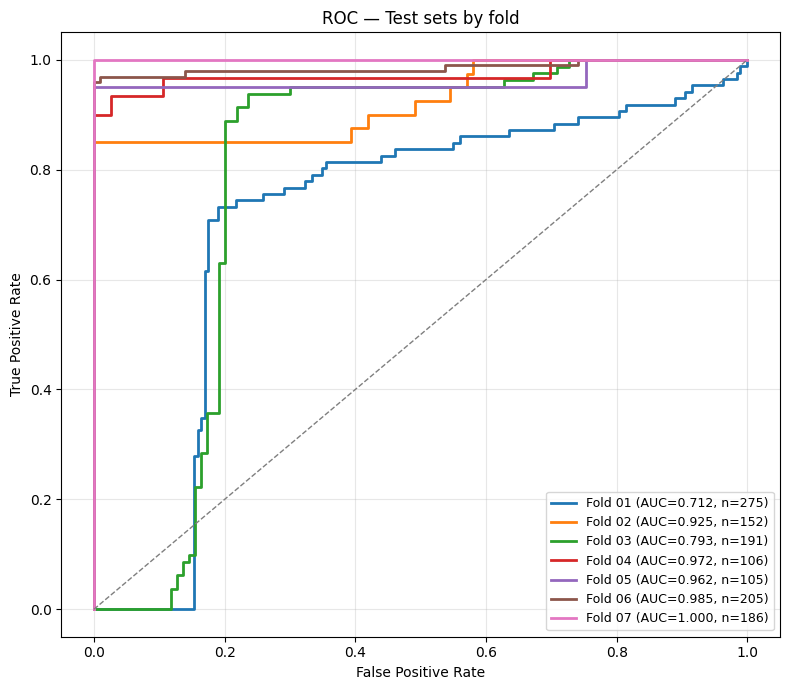

Saved combined ROC plot to: /content/drive/MyDrive/CD/2Bio_SHAP_node6/roc_curves_all_folds.png


In [ ]:
# === Load per-fold weights & test sets, plot ROC with AUC for each fold ===
# Assumes these are already defined from your training script:
#   save_dir, K_FOLDS, BATCH_SIZE, ImageSequence, label_for_file
#   (and all data-loading helpers/ID_TO_FEAT used by ImageSequence)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow import keras

auc_rows = []
roc_data = []  # list of (fold_idx, fpr, tpr, auc, n)

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir = Path(save_dir) / f"fold_{fold_idx:02d}"
    weights_file = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list = fold_dir / "test_files.txt"

    if not weights_file.exists() or not test_list.exists():
        print(f"(Fold {fold_idx:02d}) Missing weights or test_files.txt; skipping.")
        continue

    # Load test file paths
    test_files = [Path(line.strip()) for line in test_list.read_text().splitlines() if line.strip()]
    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    # Eval generator (no shuffle, no noise)
    test_gen = ImageSequence(test_files, batch_size=BATCH_SIZE, shuffle=False, add_noise=False)

    # Load model and predict
    model = keras.models.load_model(str(weights_file))
    probs = model.predict(test_gen, verbose=0).ravel().astype(float)
    y_true = np.array([label_for_file(f) for f in test_gen.files], dtype=int)

    if len(np.unique(y_true)) < 2:
        print(f"(Fold {fold_idx:02d}) Only one class present; ROC/AUC undefined.")
        auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": np.nan})
        continue

    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_val = roc_auc_score(y_true, probs)

    auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": float(auc_val)})
    roc_data.append((fold_idx, fpr, tpr, auc_val, len(y_true)))
    print(f"Fold {fold_idx:02d} | TEST AUC = {auc_val:.4f} | n={len(y_true)}")

# Save AUCs table
if auc_rows:
    auc_df = pd.DataFrame(auc_rows).sort_values("fold")
    auc_df.to_csv(Path(save_dir) / "auc_by_fold.csv", index=False)

# Plot all ROC curves in one figure with AUC in legend
if roc_data:
    plt.figure(figsize=(8, 7))
    for fold_idx, fpr, tpr, auc_val, n in roc_data:
        plt.plot(fpr, tpr, linewidth=2, label=f"Fold {fold_idx:02d} (AUC={auc_val:.3f}, n={n})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC — Test sets by fold")
    plt.legend(loc="lower right", fontsize=9, frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out_png = Path(save_dir) / "roc_curves_all_folds.png"
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved combined ROC plot to: {out_png}")
else:
    print("No ROC data plotted (no valid folds).")

In [ ]:
valid_test_aucs

[0.7116402116402116,
 0.925,
 0.7929292929292929,
 0.9723684210526315,
 0.9623529411764705,
 0.9852997327224131,
 1.0]

In [ ]:
fold_test_accs_at_05

[0.6072727272727273,
 0.9605263157894737,
 0.5759162303664922,
 0.9622641509433962,
 0.9619047619047619,
 0.8146341463414634,
 1.0]

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix
)

SAVE_DIR = Path(save_dir)  # uses your existing variable
rows = []

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir = SAVE_DIR / f"fold_{fold_idx:02d}"
    pred_csv = fold_dir / "test_predictions.csv"

    # If you didn't save test_predictions.csv, fall back to recomputing:
    if pred_csv.exists():
        dfp = pd.read_csv(pred_csv)
        y_true = dfp["y_true"].astype(int).to_numpy()
        probs  = dfp["prob1"].astype(float).to_numpy()
    else:
        # Fallback: rebuild from weights + file list (same as your ROC code)
        weights_file = fold_dir / f"best_fold_{fold_idx:02d}.h5"
        test_list    = fold_dir / "test_files.txt"
        if not weights_file.exists() or not test_list.exists():
            print(f"(Fold {fold_idx:02d}) Missing predictions and weights/test list; skipping.")
            continue
        test_files = [Path(line.strip()) for line in test_list.read_text().splitlines() if line.strip()]
        test_gen   = ImageSequence(test_files, batch_size=BATCH_SIZE, shuffle=False, add_noise=False)
        model      = keras.models.load_model(str(weights_file))
        probs      = model.predict(test_gen, verbose=0).ravel().astype(float)
        y_true     = np.array([label_for_file(f) for f in test_gen.files], dtype=int)

    if len(y_true) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    y_pred = (probs >= 0.5).astype(int)

    # Confusion matrix -> TN, FP, FN, TP (ensure both labels exist)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
    else:
        # Handle degenerate case (one class only)
        tn = fp = fn = tp = 0
        if np.all(y_true == 0):
            tn = int((y_pred == 0).sum()); fp = int((y_pred == 1).sum())
        elif np.all(y_true == 1):
            tp = int((y_pred == 1).sum()); fn = int((y_pred == 0).sum())

    # Metrics
    acc   = accuracy_score(y_true, y_pred)
    # zero_division=0 avoids warnings if a class is missing
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)           # sensitivity
    spec  = (tn / (tn + fp)) if (tn + fp) > 0 else 0.0
    f1    = f1_score(y_true, y_pred, zero_division=0)
    bacc  = balanced_accuracy_score(y_true, y_pred)

    rows.append({
        "fold": fold_idx,
        "n_test": len(y_true),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Accuracy": acc,
        "Precision": prec,
        "Recall(Sens)": rec,
        "Specificity": spec,
        "F1": f1,
        "BalancedAcc": bacc,
    })

# Assemble table
if not rows:
    print("No metrics computed (no valid folds).")
else:
    metrics_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)

    # Mean row (exclude counts and confusion cells from the mean)
    mean_row = {
        "fold": "MEAN",
        "n_test": metrics_df["n_test"].sum(),
        "TP": metrics_df["TP"].sum(),
        "FP": metrics_df["FP"].sum(),
        "TN": metrics_df["TN"].sum(),
        "FN": metrics_df["FN"].sum(),
        "Accuracy": metrics_df["Accuracy"].mean(),
        "Precision": metrics_df["Precision"].mean(),
        "Recall(Sens)": metrics_df["Recall(Sens)"].mean(),
        "Specificity": metrics_df["Specificity"].mean(),
        "F1": metrics_df["F1"].mean(),
        "BalancedAcc": metrics_df["BalancedAcc"].mean(),
    }

    # Pretty print
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', 200, 'display.float_format', '{:.4f}'.format):
        print(metrics_df.to_string(index=False))
        print("\nMEAN over folds (macro mean of metrics):")
        print(pd.DataFrame([mean_row]).to_string(index=False))

    # Save
    out_csv = SAVE_DIR / "metrics_by_fold_thresh_0p5.csv"
    metrics_df.to_csv(out_csv, index=False)
    # Also append the mean row at the end of the file for convenience
    pd.DataFrame([mean_row]).to_csv(out_csv, mode="a", index=False, header=False)
    print(f"\nSaved per-fold metrics to: {out_csv}")


 fold  n_test  TP  FP  TN  FN  Accuracy  Precision  Recall(Sens)  Specificity     F1  BalancedAcc
    1     275   0  22 167  86    0.6073     0.0000        0.0000       0.8836 0.0000       0.4418
    2     152  34   0 112   6    0.9605     1.0000        0.8500       1.0000 0.9189       0.9250
    3     191   0   0 110  81    0.5759     0.0000        0.0000       1.0000 0.0000       0.5000
    4     106  28   2  74   2    0.9623     0.9333        0.9333       0.9737 0.9333       0.9535
    5     105  19   3  82   1    0.9619     0.8636        0.9500       0.9647 0.9048       0.9574
    6     205  59   0 108  38    0.8146     1.0000        0.6082       1.0000 0.7564       0.8041
    7     186  51   0 135   0    1.0000     1.0000        1.0000       1.0000 1.0000       1.0000

MEAN over folds (macro mean of metrics):
fold  n_test  TP  FP  TN  FN  Accuracy  Precision  Recall(Sens)  Specificity     F1  BalancedAcc
MEAN    1220 191  27 788 214    0.8404     0.6853        0.6202       0.9746 

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, roc_curve
)
from tensorflow import keras  # only needed if recomputing predictions

SAVE_DIR = Path(save_dir)  # uses your existing variable
rows_youden = []

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir = SAVE_DIR / f"fold_{fold_idx:02d}"
    pred_csv = fold_dir / "test_predictions.csv"

    # --- Get test probs & labels (prefer CSV; fallback to model) ---
    if pred_csv.exists():
        dfp = pd.read_csv(pred_csv)
        y_true = dfp["y_true"].astype(int).to_numpy()
        probs  = dfp["prob1"].astype(float).to_numpy()
    else:
        # Fallback: rebuild from weights + file list
        weights_file = fold_dir / f"best_fold_{fold_idx:02d}.h5"
        test_list    = fold_dir / "test_files.txt"
        if not weights_file.exists() or not test_list.exists():
            print(f"(Fold {fold_idx:02d}) Missing predictions and weights/test list; skipping.")
            continue
        test_files = [Path(line.strip()) for line in test_list.read_text().splitlines() if line.strip()]
        test_gen   = ImageSequence(test_files, batch_size=BATCH_SIZE, shuffle=False, add_noise=False)
        model      = keras.models.load_model(str(weights_file))
        probs      = model.predict(test_gen, verbose=0).ravel().astype(float)
        y_true     = np.array([label_for_file(f) for f in test_gen.files], dtype=int)

    if len(y_true) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue
    if len(np.unique(y_true)) < 2:
        print(f"(Fold {fold_idx:02d}) Only one class present; Youden J undefined. Skipping.")
        continue

    # --- Compute Youden J on the TEST set and get the best threshold ---
    fpr, tpr, thr = roc_curve(y_true, probs)      # thr are probability thresholds
    J = tpr - fpr
    j_idx = int(np.argmax(J))
    t_star = float(thr[j_idx])                    # Youden-optimal test threshold
    J_star = float(J[j_idx])

    # --- Binarize at t* and compute metrics ---
    y_pred = (probs >= t_star).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0
        if np.all(y_true == 0):
            tn = int((y_pred == 0).sum()); fp = int((y_pred == 1).sum())
        elif np.all(y_true == 1):
            tp = int((y_pred == 1).sum()); fn = int((y_pred == 0).sum())

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)      # sensitivity
    spec  = (tn / (tn + fp)) if (tn + fp) > 0 else 0.0
    f1    = f1_score(y_true, y_pred, zero_division=0)
    bacc  = balanced_accuracy_score(y_true, y_pred)

    rows_youden.append({
        "fold": fold_idx,
        "n_test": len(y_true),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Threshold_YoudenTest": t_star,
        "YoudenJ_Test": J_star,
        "Accuracy": acc,
        "Precision": prec,
        "Recall(Sens)": rec,
        "Specificity": spec,
        "F1": f1,
        "BalancedAcc": bacc,
    })

# --- Assemble table, print, and save ---
if not rows_youden:
    print("No metrics computed at test-set Youden thresholds (no valid folds).")
else:
    dfY = pd.DataFrame(rows_youden).sort_values("fold").reset_index(drop=True)

    mean_row = {
        "fold": "MEAN",
        "n_test": dfY["n_test"].sum(),
        "TP": dfY["TP"].sum(),
        "FP": dfY["FP"].sum(),
        "TN": dfY["TN"].sum(),
        "FN": dfY["FN"].sum(),
        "Threshold_YoudenTest": dfY["Threshold_YoudenTest"].mean(),
        "YoudenJ_Test": dfY["YoudenJ_Test"].mean(),
        "Accuracy": dfY["Accuracy"].mean(),
        "Precision": dfY["Precision"].mean(),
        "Recall(Sens)": dfY["Recall(Sens)"].mean(),
        "Specificity": dfY["Specificity"].mean(),
        "F1": dfY["F1"].mean(),
        "BalancedAcc": dfY["BalancedAcc"].mean(),
    }

    with pd.option_context('display.max_rows', None,
                           'display.max_colwidth', 200,
                           'display.float_format', '{:.4f}'.format):
        print(dfY.to_string(index=False))
        print("\nMEAN over folds (macro mean of metrics; counts summed):")
        print(pd.DataFrame([mean_row]).to_string(index=False))

    out_csv = SAVE_DIR / "metrics_by_fold_thresh_YoudenTEST.csv"
    dfY.to_csv(out_csv, index=False)
    pd.DataFrame([mean_row]).to_csv(out_csv, mode="a", index=False, header=False)
    print(f"\nSaved per-fold (Youden-on-TEST) metrics to: {out_csv}")


 fold  n_test  TP  FP  TN  FN  Threshold_YoudenTest  YoudenJ_Test  Accuracy  Precision  Recall(Sens)  Specificity     F1  BalancedAcc
    1     275  63  36 153  23                0.0678        0.5421    0.7855     0.6364        0.7326       0.8095 0.6811       0.7710
    2     152  34   0 112   6                0.8432        0.8500    0.9605     1.0000        0.8500       1.0000 0.9189       0.9250
    3     191  76  26  84   5                0.1087        0.7019    0.8377     0.7451        0.9383       0.7636 0.8306       0.8510
    4     106  28   2  74   2                0.5498        0.9070    0.9623     0.9333        0.9333       0.9737 0.9333       0.9535
    5     105  19   0  85   1                0.9909        0.9500    0.9905     1.0000        0.9500       1.0000 0.9744       0.9750
    6     205  94   1 107   3                0.2570        0.9598    0.9805     0.9895        0.9691       0.9907 0.9792       0.9799
    7     186  51   0 135   0                0.9921        1.0

Mean TPR at fixed FPRs (unweighted, 7 folds):
  FPR=0.01 -> mean TPR=0.6670 (±0.4582)
  FPR=0.02 -> mean TPR=0.6670 (±0.4582)
  FPR=0.03 -> mean TPR=0.6718 (±0.4612)
  FPR=0.04 -> mean TPR=0.6718 (±0.4612)
  FPR=0.05 -> mean TPR=0.6718 (±0.4612)
  FPR=0.06 -> mean TPR=0.6718 (±0.4612)
  FPR=0.07 -> mean TPR=0.6718 (±0.4612)
  FPR=0.08 -> mean TPR=0.6718 (±0.4612)
  FPR=0.09 -> mean TPR=0.6718 (±0.4612)
  FPR=0.10 -> mean TPR=0.6718 (±0.4612)
  FPR=0.11 -> mean TPR=0.6765 (±0.4645)
  FPR=0.12 -> mean TPR=0.6818 (±0.4557)
  FPR=0.13 -> mean TPR=0.6854 (±0.4499)
  FPR=0.14 -> mean TPR=0.6904 (±0.4453)
  FPR=0.15 -> mean TPR=0.6921 (±0.4426)
  FPR=0.16 -> mean TPR=0.7563 (±0.3343)
  FPR=0.17 -> mean TPR=0.8066 (±0.2661)
  FPR=0.18 -> mean TPR=0.8305 (±0.2317)
  FPR=0.19 -> mean TPR=0.8305 (±0.2317)
  FPR=0.20 -> mean TPR=0.9096 (±0.0942)


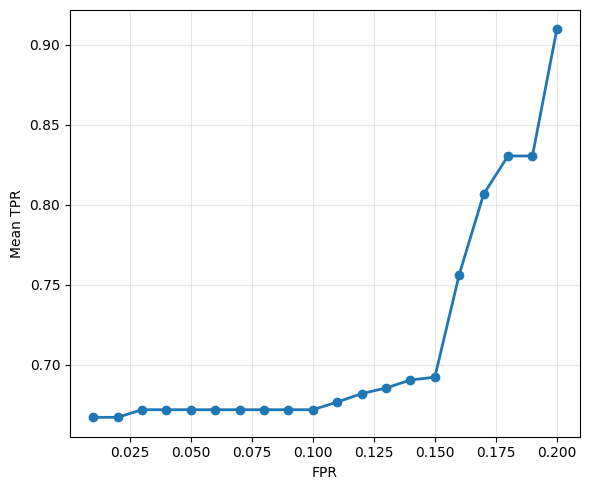

Saved mean TPR plot to: /content/drive/MyDrive/CD/2Bio_SHAP_node6/mean_tpr_at_fixed_fprs.png


In [ ]:
# === Mean TPR at fixed FPRs across folds (right-continuous step function) ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# prerequisites: roc_data, save_dir
assert 'roc_data' in globals() and len(roc_data) > 0, "roc_data is empty; run ROC computation first."
assert 'save_dir' in globals(), "save_dir missing."

save_dir = Path(save_dir)
target_fprs = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20], dtype=float)

# If True, average folds weighted by their test-set size n; else plain mean.
WEIGHTED = False

per_fold_rows = []
per_fold_tpr = []
fold_sizes = []

for fold_idx, fpr, tpr, auc_val, n in roc_data:
    # 1) Collapse duplicate FPRs by keeping the MAX TPR at each FPR
    ufpr, inv = np.unique(fpr, return_inverse=True)
    tpr_max = np.zeros_like(ufpr, dtype=float)
    np.maximum.at(tpr_max, inv, tpr)

    # 2) Make it right-continuous / nondecreasing
    tpr_rc = np.maximum.accumulate(tpr_max)

    # 3) Evaluate stepwise TPR at or below the target FPRs (no linear interp)
    idxs = np.searchsorted(ufpr, target_fprs, side='right') - 1
    idxs = np.clip(idxs, 0, len(ufpr) - 1)
    tprs_at_targets = tpr_rc[idxs]

    per_fold_tpr.append(tprs_at_targets)
    fold_sizes.append(int(n))

    row = {"fold": int(fold_idx), "n": int(n)}
    row.update({f"tpr@{fp:.2f}": float(tv) for fp, tv in zip(target_fprs, tprs_at_targets)})
    per_fold_rows.append(row)

per_fold_tpr = np.vstack(per_fold_tpr)  # shape: (num_folds, 4)
fold_sizes = np.asarray(fold_sizes, dtype=float)

if WEIGHTED:
    w = fold_sizes / fold_sizes.sum()
    mean_tpr = (per_fold_tpr * w[:, None]).sum(axis=0)
    # weighted std (sqrt of weighted variance)
    var = (w[:, None] * (per_fold_tpr - mean_tpr) ** 2).sum(axis=0)
    std_tpr = np.sqrt(var)
else:
    mean_tpr = per_fold_tpr.mean(axis=0)
    std_tpr  = per_fold_tpr.std(axis=0, ddof=1) if per_fold_tpr.shape[0] > 1 else np.zeros_like(mean_tpr)

# Save CSVs
per_fold_df = pd.DataFrame(per_fold_rows).sort_values("fold")
per_fold_df.to_csv(save_dir / "tpr_at_fixed_fprs_by_fold.csv", index=False)

mean_df = pd.DataFrame({"fpr": target_fprs, "mean_tpr": mean_tpr, "std_tpr": std_tpr})
mean_df.to_csv(save_dir / "tpr_at_fixed_fprs_mean.csv", index=False)

# Console summary
avg_kind = "weighted" if WEIGHTED else "unweighted"
print(f"Mean TPR at fixed FPRs ({avg_kind}, {per_fold_tpr.shape[0]} folds):")
for fp, mt, st in zip(target_fprs, mean_tpr, std_tpr):
    print(f"  FPR={fp:.2f} -> mean TPR={mt:.4f} (±{st:.4f})")

# Plot mean TPR vs fixed FPRs
plt.figure(figsize=(6, 5))
plt.plot(target_fprs, mean_tpr, marker="o", linewidth=2)
plt.xlabel("FPR")
plt.ylabel("Mean TPR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
out_png2 = save_dir / ("mean_tpr_at_fixed_fprs_weighted.png" if WEIGHTED else "mean_tpr_at_fixed_fprs.png")
plt.savefig(out_png2, dpi=200)
plt.show()
print(f"Saved mean TPR plot to: {out_png2}")


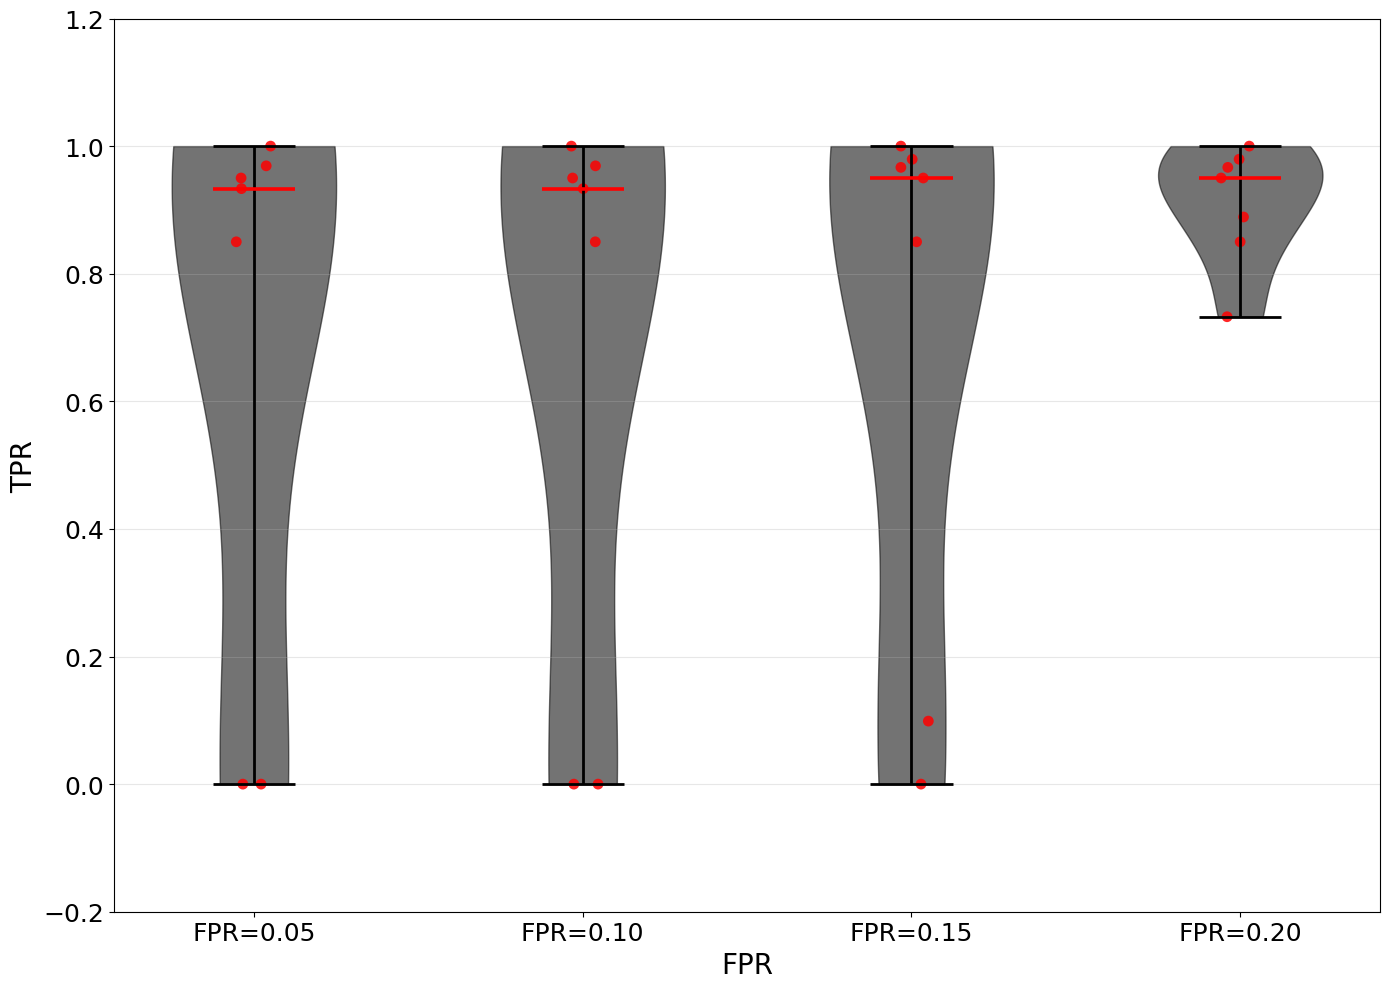

Saved violin plot to: /content/drive/MyDrive/CD/2Bio_SHAP_node6/tpr_violin_0p05_0p10_0p15_0p20_black_red.png


In [ ]:
# === Violin plots of TPR across folds at selected FPRs (black violins, red medians & points) ===
selected_fprs = np.array([0.05, 0.10, 0.15, 0.20], dtype=float)

# map each selected FPR to the nearest index in target_fprs
sel_idx = [int(np.argmin(np.abs(target_fprs - fp))) for fp in selected_fprs]

# collect TPR vectors across folds at those indices
data_list = [per_fold_tpr[:, j] for j in sel_idx]

# optional: save the raw values table
viol_df = pd.DataFrame({f"tpr@{selected_fprs[i]:.2f}": data_list[i] for i in range(len(selected_fprs))})
viol_df.insert(0, "fold", [int(r["fold"]) for r in per_fold_rows])
viol_df.to_csv(save_dir / "tpr_violin_four_fprs_by_fold.csv", index=False)

# colors
COLOR_VIOLIN = "black"
COLOR_HILITE = "red"

# sizing
LABEL_FONTSIZE = 20
TICK_FONTSIZE  = 18
DOT_SIZE       = 60      # <- bigger dots
LINEWIDTH_MED  = 2.6
LINEWIDTH_EXT  = 2.0

fig, ax = plt.subplots(figsize=(14, 10))
parts = ax.violinplot(
    dataset=data_list,
    positions=np.arange(1, len(selected_fprs) + 1),
    showmeans=False, showmedians=True, showextrema=True
)

# black violins
for pc in parts['bodies']:
    pc.set_facecolor(COLOR_VIOLIN)
    pc.set_edgecolor(COLOR_VIOLIN)
    pc.set_alpha(0.55)

# black whiskers/bars; red medians
if 'cmins' in parts:    parts['cmins'].set_color(COLOR_VIOLIN);  parts['cmins'].set_linewidth(LINEWIDTH_EXT)
if 'cmaxes' in parts:   parts['cmaxes'].set_color(COLOR_VIOLIN); parts['cmaxes'].set_linewidth(LINEWIDTH_EXT)
if 'cbars' in parts:    parts['cbars'].set_color(COLOR_VIOLIN);  parts['cbars'].set_linewidth(LINEWIDTH_EXT)
if 'cmedians' in parts: parts['cmedians'].set_color(COLOR_HILITE); parts['cmedians'].set_linewidth(LINEWIDTH_MED)

# overlay per-fold points (red) with slight jitter
rng = np.random.default_rng(123)
for i, vals in enumerate(data_list, start=1):
    jitter = rng.uniform(-0.06, 0.06, size=vals.shape[0])
    ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
               s=DOT_SIZE, alpha=0.85, color=COLOR_HILITE, edgecolors='none')

ax.set_xticks(np.arange(1, len(selected_fprs) + 1))
ax.set_xticklabels([f"FPR={fp:.2f}" for fp in selected_fprs], fontsize=TICK_FONTSIZE)
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel("FPR", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("TPR", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
ax.grid(axis="y", alpha=0.3)

out_violin = save_dir / "tpr_violin_0p05_0p10_0p15_0p20_black_red.png"
fig.tight_layout()
fig.savefig(out_violin, dpi=200)
plt.show()
print(f"Saved violin plot to: {out_violin}")


### Test and validation set in each fold

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

base = Path("/content/drive/MyDrive/CD/2Bio_SHAP_node6/")  # your save_dir
rows = []

for fold_dir in sorted(base.glob("fold_*")):
    f = fold_dir.name
    # read lists we wrote earlier
    val_ids  = pd.read_csv(fold_dir / "val_ids.csv")["val_ids"].astype(int).tolist()
    test_ids = pd.read_csv(fold_dir / "test_ids.csv")["test_ids"].astype(int).tolist()

    # read positive-id CSVs if you saved them; else compute on the fly
    if (fold_dir / "pos_val_ids.csv").exists():
        pos_val_ids  = pd.read_csv(fold_dir / "pos_val_ids.csv").iloc[:,0].astype(int).tolist()
        pos_test_ids = pd.read_csv(fold_dir / "pos_test_ids.csv").iloc[:,0].astype(int).tolist()
    else:
        # fallback: compute using your POS_PATIENTS set
        POS_PATIENTS = {1, 2, 16, 19, 21, 22, 25, 37, 39, 43, 44, 47, 50, 56, 58, 62, 65, 66, 73, 78}
        pos_val_ids  = sorted([i for i in val_ids  if i in POS_PATIENTS])
        pos_test_ids = sorted([i for i in test_ids if i in POS_PATIENTS])

    rows.append({
        "fold": f,
        "VAL_pos_n": len(pos_val_ids),
        "VAL_pos_IDs": pos_val_ids,
        "TEST_pos_n": len(pos_test_ids),
        "TEST_pos_IDs": pos_test_ids
    })

summary = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)

# Pretty print
with pd.option_context('display.max_colwidth', 200):
    print(summary.to_string(index=False))

# Highlight any problematic folds (no positives)
bad_val  = summary[summary["VAL_pos_n"]  == 0]["fold"].tolist()
bad_test = summary[summary["TEST_pos_n"] == 0]["fold"].tolist()
if bad_val or bad_test:
    print("\n[WARN] Folds with no positives:",
          f"VAL={bad_val if bad_val else 'OK'}, TEST={bad_test if bad_test else 'OK'}")
else:
    print("\nAll folds have at least one positive in both VAL and TEST. 👍")


   fold  VAL_pos_n VAL_pos_IDs  TEST_pos_n TEST_pos_IDs
fold_01          1        [16]           2     [43, 47]
fold_02          1        [25]           2      [1, 22]
fold_03          1        [16]           2     [37, 78]
fold_04          1        [25]           2      [2, 16]
fold_05          1        [16]           2     [58, 62]
fold_06          1        [16]           2     [25, 65]
fold_07          1        [16]           2     [44, 50]

All folds have at least one positive in both VAL and TEST. 👍
